## TÊN ĐỒ ÁN: SIÊU PHÂN GIẢI ẢNH VỆ TINH (SUPER RESOLUTION)


### Cách chạy notebook

- **Lần đầu chạy đầy đủ:** chạy lần lượt Phần 1 đến Phần 10 để tiền xử lý dữ liệu, EDA, train và đánh giá.
- **Khi bảo vệ/demo:** chạy Phần 1, Phần 4, Phần 5, Phần 6, Phần 7, sau đó chạy Phần 11 để load model đã lưu và demo.
- **Phần 2 và Phần 3:** chỉ chạy lại khi đổi dữ liệu hoặc muốn tạo lại thống kê.


## PHẦN 1. IMPORT VÀ CẤU HÌNH


In [3]:
# Import các thư viện cần thiết
import os
import shutil
import random
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

import torch
import math
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import torch.nn.functional as F

# Cố định seed để các lần chia dữ liệu và huấn luyện có thể tái lập.
SEED = 40
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("-> Đã import xong các thư viện cần thiết!")

-> Đã import xong các thư viện cần thiết!


## PHẦN 2. TIỀN XỬ LÝ DỮ LIỆU (CHỈ CHẠY 1 LẦN)


### Sơ đồ pipeline tổng thể

```text
Raw Image
↓
Preprocessing
↓
Generate LR
↓
Train Model
↓
Super Resolution Output
↓
Evaluation
```


### 2.1 Clean ảnh và chuyển sang PNG

Chỉ chạy một lần nếu dữ liệu đã được tạo trong `Clean_HR_Data`.


In [ ]:
# RAW DATA -> CLEANING & CHUYỂN ĐỔI PNG LOSSLESS


def clean_and_convert_dataset(raw_dir, clean_dir):
    """Làm sạch dữ liệu ảnh, convert toàn bộ về RGB và lưu PNG lossless."""
    os.makedirs(clean_dir, exist_ok=True)

    valid_extensions = (".jpg", ".jpeg", ".png", ".tif", ".tiff")
    valid_files = sorted(
        filename
        for filename in os.listdir(raw_dir)
        if filename.lower().endswith(valid_extensions)
    )

    converted_count = 0
    skipped_count = 0

    print(f"Đang xử lý dữ liệu từ {raw_dir}...")
    print(f"- Tìm thấy {len(valid_files)} file ảnh hợp lệ.")

    for filename in valid_files:
        img_path = os.path.join(raw_dir, filename)
        try:
            with Image.open(img_path) as img:
                rgb_img = img.convert("RGB")

            new_filename = f"clean_hr_{converted_count:04d}.png"
            output_path = os.path.join(clean_dir, new_filename)
            rgb_img.save(output_path, "PNG", optimize=True)
            converted_count += 1
        except Exception as e:
            skipped_count += 1
            print(f"[SKIP] {filename}: {e}")

    print("\nTÓM TẮT CLEANING:")
    print(f"- Tổng file hợp lệ: {len(valid_files)}")
    print(f"- Số file convert thành công: {converted_count}")
    print(f"- Số file bị bỏ qua: {skipped_count}")
    print(f"-> Đã lưu dữ liệu PNG chuẩn vào {clean_dir}")


# Chỉ chạy clean khi chưa có dữ liệu clean.
raw_dir = "./WorldStrat/worldstrat"
clean_dir = "./Clean_HR_Data"
force_preprocess = False

clean_ready = (
    os.path.exists(clean_dir)
    and len([f for f in os.listdir(clean_dir) if f.lower().endswith(".png")]) > 0
)

if clean_ready and not force_preprocess:
    print(f"- Đã có dữ liệu clean trong {clean_dir}, bỏ qua bước clean.")
elif os.path.exists(raw_dir):
    clean_and_convert_dataset(raw_dir=raw_dir, clean_dir=clean_dir)
else:
    raise FileNotFoundError(
        f"Không tìm thấy raw_dir={raw_dir}. Nếu đã có Clean_HR_Data thì không cần chạy cell này."
    )


### 2.2 Chia dữ liệu Train / Val / Test

Chỉ chạy lại khi muốn chia lại dataset từ đầu.


In [ ]:
# CHIA TẬP DỮ LIỆU (TRAIN 70% - VAL 15% - TEST 15%)


def split_dataset(clean_dir, base_output_dir):
    all_images = sorted(f for f in os.listdir(clean_dir) if f.lower().endswith(".png"))
    rng = random.Random(SEED)
    rng.shuffle(all_images)

    total = len(all_images)
    train_end = int(total * 0.7)
    val_end = int(total * 0.85)

    train_files = all_images[:train_end]
    val_files = all_images[train_end:val_end]
    test_files = all_images[val_end:]

    splits = {"Train": train_files, "Val": val_files, "Test": test_files}
    os.makedirs(base_output_dir, exist_ok=True)

    for split_name, files in splits.items():
        split_dir = os.path.join(base_output_dir, split_name)
        if os.path.exists(split_dir):
            shutil.rmtree(split_dir)
        os.makedirs(split_dir, exist_ok=True)

        for filename in files:
            src = os.path.join(clean_dir, filename)
            dst = os.path.join(split_dir, filename)
            shutil.copy2(src, dst)

    total_after_split = sum(len(files) for files in splits.values())
    print("TÓM TẮT SPLIT DATASET:")
    print(f"- Tổng số ảnh đầu vào: {total}")
    for split_name, files in splits.items():
        print(f"- {split_name}: {len(files)} ảnh")
    print(f"- Tổng số ảnh sau khi chia: {total_after_split}")

    if total_after_split != total:
        raise ValueError("Số lượng ảnh sau khi chia không khớp với dữ liệu đầu vào.")

    print("-> Chia dữ liệu thành công và đã làm sạch thư mục split cũ.")


clean_dir = "./Clean_HR_Data"
base_output_dir = "./Dataset"
force_resplit = False

split_ready = all(
    os.path.exists(os.path.join(base_output_dir, split_name))
    and len(
        [
            f
            for f in os.listdir(os.path.join(base_output_dir, split_name))
            if f.lower().endswith(".png")
        ]
    )
    > 0
    for split_name in ["Train", "Val", "Test"]
)

if split_ready and not force_resplit:
    print("- Dataset đã được chia sẵn trong ./Dataset, bỏ qua bước split.")
else:
    split_dataset(clean_dir=clean_dir, base_output_dir=base_output_dir)


## PHẦN 3. PHÂN TÍCH DỮ LIỆU (EDA)


### 3.1 Thống kê nhanh bộ dữ liệu

Cell này chỉ dùng để quan sát kích thước, kênh màu và phân bố pixel, Không cần chạy lại



BẮT ĐẦU PHÂN TÍCH EDA (800 ảnh)...

KÍCH THƯỚC ẢNH:
  - Chiều rộng (Min - Max - Mean): 1054 - 1054 - 1054 px
  - Chiều cao  (Min - Max - Mean): 1054 - 1054 - 1054 px
KHÔNG GIAN MÀU:
  - RGB (3): 800 ảnh (100.0%)

CẢNH BÁO TIỀN XỬ LÝ:
  - Ảnh nhỏ hơn patch_size=96: 0
  - Ảnh có kích thước không chia hết cho scale=2: 0
  - File lỗi khi đọc: 0

Nhận xét: Bộ dữ liệu đã được convert về RGB, nhưng vẫn cần crop/resize hợp lý để train ổn định.


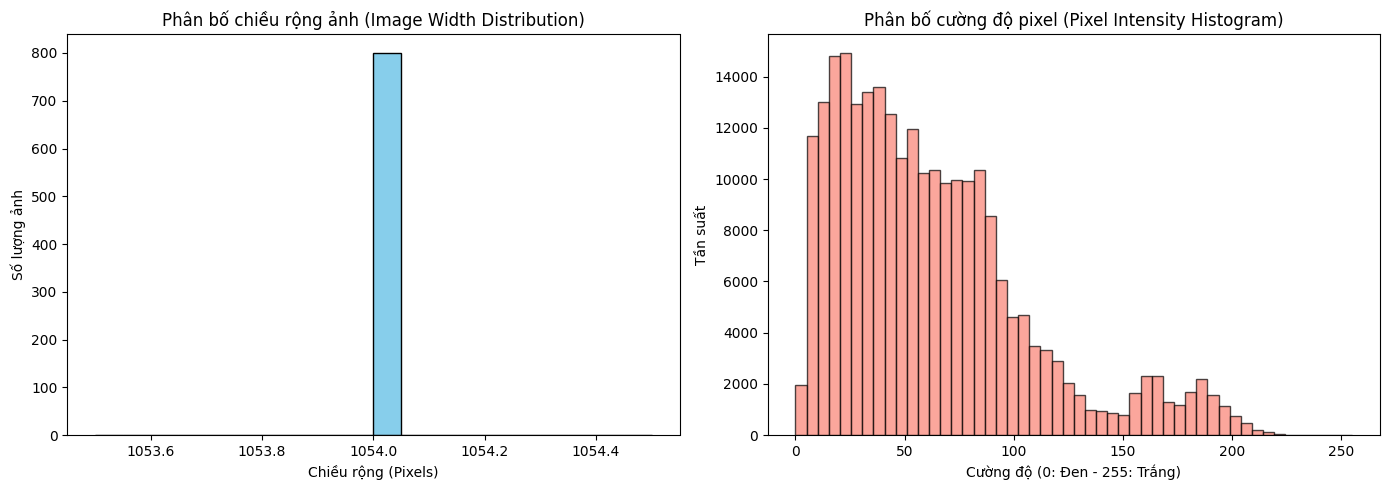

In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA) - PHÂN TÍCH TẬP CLEAN SAU TIỀN XỬ LÝ


def analyze_dataset_eda(raw_dir, patch_size=96, scale=2):
    """Phân tích thống kê tập dữ liệu đã clean trước khi chia train/val/test."""
    widths, heights = [], []
    channels_info = {"Grayscale (1)": 0, "RGB (3)": 0, "RGBA (4)": 0, "Khác": 0}
    pixel_intensities = []
    small_images = []
    non_divisible_images = []
    failed_files = []

    valid_ext = (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    files = sorted(f for f in os.listdir(raw_dir) if f.lower().endswith(valid_ext))

    if not files:
        print("Thư mục trống hoặc không có ảnh!")
        return

    print(f"BẮT ĐẦU PHÂN TÍCH EDA ({len(files)} ảnh)...\n")

    for filename in files:
        img_path = os.path.join(raw_dir, filename)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)

                if img.mode == "L":
                    channels_info["Grayscale (1)"] += 1
                elif img.mode == "RGB":
                    channels_info["RGB (3)"] += 1
                elif img.mode == "RGBA":
                    channels_info["RGBA (4)"] += 1
                else:
                    channels_info["Khác"] += 1

                if len(pixel_intensities) < 100 * 50 * 50:
                    img_small = img.resize((50, 50)).convert("L")
                    pixel_intensities.extend(np.array(img_small).flatten())

            if w < patch_size or h < patch_size:
                small_images.append((filename, w, h))

            if w % scale != 0 or h % scale != 0:
                non_divisible_images.append((filename, w, h))
        except Exception as e:
            failed_files.append((filename, str(e)))
            print(f"[EDA-ERROR] {filename}: {e}")

    if not widths or not heights:
        print("Không đọc được ảnh hợp lệ nào để phân tích.")
        return

    print("KÍCH THƯỚC ẢNH:")
    print(
        f"  - Chiều rộng (Min - Max - Mean): {min(widths)} - {max(widths)} - {int(np.mean(widths))} px"
    )
    print(
        f"  - Chiều cao  (Min - Max - Mean): {min(heights)} - {max(heights)} - {int(np.mean(heights))} px"
    )
    print("KHÔNG GIAN MÀU:")
    total_valid = len(widths)
    for mode, count in channels_info.items():
        if count > 0:
            print(f"  - {mode}: {count} ảnh ({count / total_valid * 100:.1f}%)")

    print("\nCẢNH BÁO TIỀN XỬ LÝ:")
    print(f"  - Ảnh nhỏ hơn patch_size={patch_size}: {len(small_images)}")
    print(
        f"  - Ảnh có kích thước không chia hết cho scale={scale}: {len(non_divisible_images)}"
    )
    print(f"  - File lỗi khi đọc: {len(failed_files)}")

    if small_images:
        print(f"    Ví dụ ảnh nhỏ: {small_images[0]}")
    if non_divisible_images:
        print(f"    Ví dụ ảnh không chia hết cho scale: {non_divisible_images[0]}")

    print(
        "\nNhận xét: Bộ dữ liệu đã được convert về RGB, nhưng vẫn cần crop/resize hợp lý để train ổn định."
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(widths, bins=20, color="skyblue", edgecolor="black")
    axes[0].set_title("Phân bố chiều rộng ảnh (Image Width Distribution)")
    axes[0].set_xlabel("Chiều rộng (Pixels)")
    axes[0].set_ylabel("Số lượng ảnh")

    axes[1].hist(
        pixel_intensities, bins=50, color="salmon", edgecolor="black", alpha=0.7
    )
    axes[1].set_title("Phân bố cường độ pixel (Pixel Intensity Histogram)")
    axes[1].set_xlabel("Cường độ (0: Đen - 255: Trắng)")
    axes[1].set_ylabel("Tần suất")

    plt.tight_layout()
    plt.show()


# Chạy EDA trên tập đã clean để phản ánh đúng dữ liệu trước khi train
analyze_dataset_eda("./Clean_HR_Data")

## PHẦN 4. XÂY DỰNG DATASET VÀ DATALOADER


### 4.1 Tạo ảnh chất lượng thấp (LR)

Ảnh **LR** được tạo từ HR bằng bicubic, sau đó có thể thêm Gaussian Blur nhẹ và nhiễu Gaussian để giống ảnh vệ tinh chất lượng thấp.


In [4]:
# VÒNG LẶP ON-THE-FLY DATALOADER
class SuperResolutionDataset(Dataset):
    """HR/LR cho super-resolution; LR có thể bị suy thoái kiểu ảnh vệ tinh chất lượng thấp."""

    def __init__(
        self,
        hr_dir,
        scale=2,
        patch_size=96,
        mode="train",
        satellite_degrade=True,
        blur_radius_val=0.3,
        noise_sigma_range=(1.5, 3.5),
    ):
        if mode not in {"train", "val"}:
            raise ValueError("mode phải là 'train' hoặc 'val'.")

        self.hr_dir = hr_dir
        self.scale = scale
        self.hr_patch_size = patch_size
        self.lr_patch_size = patch_size // scale
        self.mode = mode
        self.satellite_degrade = satellite_degrade
        self.blur_radius_val = blur_radius_val
        lo, hi = float(noise_sigma_range[0]), float(noise_sigma_range[1])
        if lo > hi:
            lo, hi = hi, lo
        self.noise_sigma_range = (lo, hi)
        self.noise_sigma_val = 0.5 * (lo + hi)
        self.to_tensor = transforms.ToTensor()
        self.image_names = []
        self.skipped_small = 0
        self.skipped_error = 0

        candidate_images = sorted(
            x for x in os.listdir(hr_dir) if x.lower().endswith(".png")
        )
        min_required_size = patch_size if mode == "train" else scale

        for image_name in candidate_images:
            img_path = os.path.join(hr_dir, image_name)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                if width < min_required_size or height < min_required_size:
                    self.skipped_small += 1
                    continue
                self.image_names.append(image_name)
            except Exception as e:
                self.skipped_error += 1
                print(f"[DATASET-SKIP] {image_name}: {e}")

        print(
            f"[{self.mode.upper()}] Giữ lại {len(self.image_names)} ảnh | "
            f"bỏ qua vì quá nhỏ: {self.skipped_small} | lỗi đọc ảnh: {self.skipped_error}"
        )
        if self.satellite_degrade:
            print(
                "  -> Mô phỏng LR chất lượng thấp: Gaussian Blur + nhiễu Gaussian "
                f"(σ trên thang 0–255: train ∈[{self.noise_sigma_range[0]}, {self.noise_sigma_range[1]}], "
                f"val cố định {self.noise_sigma_val:.1f})."
            )

    def __len__(self):
        return len(self.image_names)

    def _center_crop_divisible(self, img):
        width, height = img.size
        crop_width = width - (width % self.scale)
        crop_height = height - (height % self.scale)

        if crop_width == 0 or crop_height == 0:
            raise ValueError("Ảnh validation nhỏ hơn scale, không thể crop hợp lệ.")

        left = (width - crop_width) // 2
        top = (height - crop_height) // 2
        right = left + crop_width
        bottom = top + crop_height
        return img.crop((left, top, right, bottom))

    def _satellite_blur_lr(self, lr_patch):
        """Gaussian blur nhẹ trên ảnh PIL LR (sau downsample)."""
        if not self.satellite_degrade:
            return lr_patch
        if self.mode == "train":
            radius = random.uniform(0.12, 0.28)
        else:
            radius = self.blur_radius_val
        return lr_patch.filter(ImageFilter.GaussianBlur(radius=radius))

    def _satellite_noise_lr_tensor(self, lr_tensor):
        """Nhiễu Gaussian: σ theo thang cường độ 8-bit (0–255), tensor đã chuẩn hóa [0,1]."""
        if not self.satellite_degrade:
            return lr_tensor
        if self.mode == "train":
            sigma_255 = random.uniform(
                self.noise_sigma_range[0], self.noise_sigma_range[1]
            )
        else:
            sigma_255 = self.noise_sigma_val
        sigma = sigma_255 / 255.0
        noise = torch.randn_like(lr_tensor) * sigma
        return torch.clamp(lr_tensor + noise, 0.0, 1.0)

    def __getitem__(self, idx):
        img_path = os.path.join(self.hr_dir, self.image_names[idx])
        with Image.open(img_path) as img:
            hr_img = img.convert("RGB")

        if self.mode == "train":
            width, height = hr_img.size
            x = random.randint(0, width - self.hr_patch_size)
            y = random.randint(0, height - self.hr_patch_size)
            hr_patch = hr_img.crop(
                (x, y, x + self.hr_patch_size, y + self.hr_patch_size)
            )
            lr_patch = hr_patch.resize(
                (self.lr_patch_size, self.lr_patch_size), Image.BICUBIC
            )

            if random.random() > 0.5:
                hr_patch = TF.hflip(hr_patch)
                lr_patch = TF.hflip(lr_patch)

            if random.random() > 0.5:
                hr_patch = TF.vflip(hr_patch)
                lr_patch = TF.vflip(lr_patch)

            rot_angle = random.choice([0, 90, 180, 270])
            hr_patch = TF.rotate(hr_patch, rot_angle)
            lr_patch = TF.rotate(lr_patch, rot_angle)
        else:
            hr_patch = self._center_crop_divisible(hr_img)
            width, height = hr_patch.size
            lr_patch = hr_patch.resize(
                (width // self.scale, height // self.scale), Image.BICUBIC
            )

        lr_patch = self._satellite_blur_lr(lr_patch)

        hr_tensor = self.to_tensor(hr_patch)
        lr_tensor = self.to_tensor(lr_patch)
        lr_tensor = self._satellite_noise_lr_tensor(lr_tensor)
        return lr_tensor, hr_tensor

### 4.2 Tạo Train Loader và Validation Loader

Cần chạy trước khi huấn luyện. Khi chỉ demo thì có thể bỏ qua cell này nếu không train.


In [ ]:
# 1. Khởi tạo Dataset cho Train và Val
train_dataset = SuperResolutionDataset(
    hr_dir="./Dataset/Train", scale=2, patch_size=96, mode="train"
)
val_dataset = SuperResolutionDataset(
    hr_dir=".
)

# 2. Khởi tạo DataLoader cho Train và Val
train_loader = DataLoader(
    dataset=train_dataset, batch_size=16, shuffle=True, num_workers=0
)
val_loader = DataLoader(dataset=val_dataset, batch_size=1, shuffle=False, num_workers=0)

if len(train_dataset) == 0:
    raise ValueError(
        "Train dataset rỗng sau bước lọc ảnh. Hãy kiểm tra patch_size hoặc dữ liệu đầu vào."
    )
if len(val_dataset) == 0:
    raise ValueError(
        "Val dataset rỗng sau bước lọc ảnh. Hãy kiểm tra dữ liệu validation."
    )

print("- Đã nạp xong Train Loader và Val Loader!")

[TRAIN] Giữ lại 560 ảnh | bỏ qua vì quá nhỏ: 0 | lỗi đọc ảnh: 0
  -> Mô phỏng LR chất lượng thấp: Gaussian Blur + nhiễu Gaussian (σ trên thang 0–255: train ∈[1.5, 3.5], val cố định 2.5).
[VAL] Giữ lại 120 ảnh | bỏ qua vì quá nhỏ: 0 | lỗi đọc ảnh: 0
  -> Mô phỏng LR chất lượng thấp: Gaussian Blur + nhiễu Gaussian (σ trên thang 0–255: train ∈[1.5, 3.5], val cố định 2.5).
- Đã nạp xong Train Loader và Val Loader!


### 4.3 Tạo Test Loader

Cần chạy khi đánh giá và khi demo cuối cùng.


In [ ]:
# Khai báo Dataset (chạy trước khi đánh giá Test)
from torch.utils.data import DataLoader

print("- Bắt đầu nạp dữ liệu Test...")

# Khởi tạo Test Dataset
test_dataset = SuperResolutionDataset(hr_dir=".

# Đóng gói vào DataLoader
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

print(f"- Đã nạp xong {len(test_dataset)} ảnh Test. Sẵn sàng đưa vào mô hình")

- Bắt đầu nạp dữ liệu Test...


[VAL] Giữ lại 120 ảnh | bỏ qua vì quá nhỏ: 0 | lỗi đọc ảnh: 0
  -> Mô phỏng LR chất lượng thấp: Gaussian Blur + nhiễu Gaussian (σ trên thang 0–255: train ∈[1.5, 3.5], val cố định 2.5).
- Đã nạp xong 120 ảnh Test. Sẵn sàng đưa vào mô hình


### 4.4 Kiểm tra batch và hiển thị dữ liệu mẫu

Dùng để kiểm tra shape và xem ảnh LR-HR trước khi train. Không bắt buộc khi bảo vệ.


In [7]:
# Kiểm tra một batch từ train_loader đã tạo ở trên
for lr_batch, hr_batch in train_loader:
    print("Kích thước batch đầu vào (LR):", lr_batch.shape)
    print("Kích thước batch đáp án (HR):", hr_batch.shape)
    break


Kích thước batch đầu vào (LR): torch.Size([16, 3, 48, 48])
Kích thước batch đáp án (HR): torch.Size([16, 3, 96, 96])


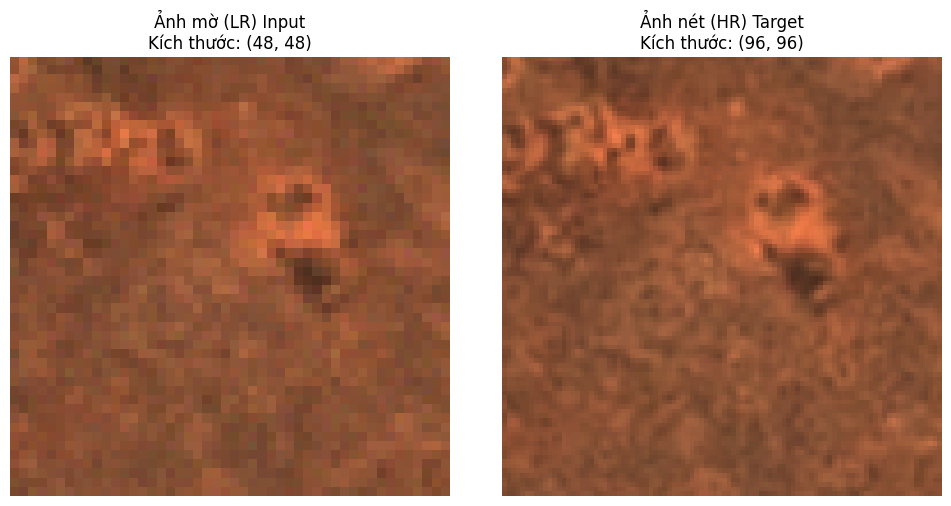

In [8]:
# HIỂN THỊ TRỰC QUAN MỘT CẶP ẢNH LR - HR TỪ DATALOADER


def visualize_batch(lr_batch, hr_batch):
    # Lấy tấm ảnh đầu tiên trong batch
    lr_img = lr_batch[0].permute(1, 2, 0).numpy()  # Chuyển [C, H, W] về [H, W, C] để vẽ
    hr_img = hr_batch[0].permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Vẽ ảnh LR (input)
    axes[0].imshow(lr_img)
    axes[0].set_title(f"Ảnh mờ (LR) Input\nKích thước: {lr_img.shape[:2]}")
    axes[0].axis("off")

    # Vẽ ảnh HR (ground truth)
    axes[1].imshow(hr_img)
    axes[1].set_title(f"Ảnh nét (HR) Target\nKích thước: {hr_img.shape[:2]}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Hiển thị thử cặp ảnh
visualize_batch(lr_batch, hr_batch)

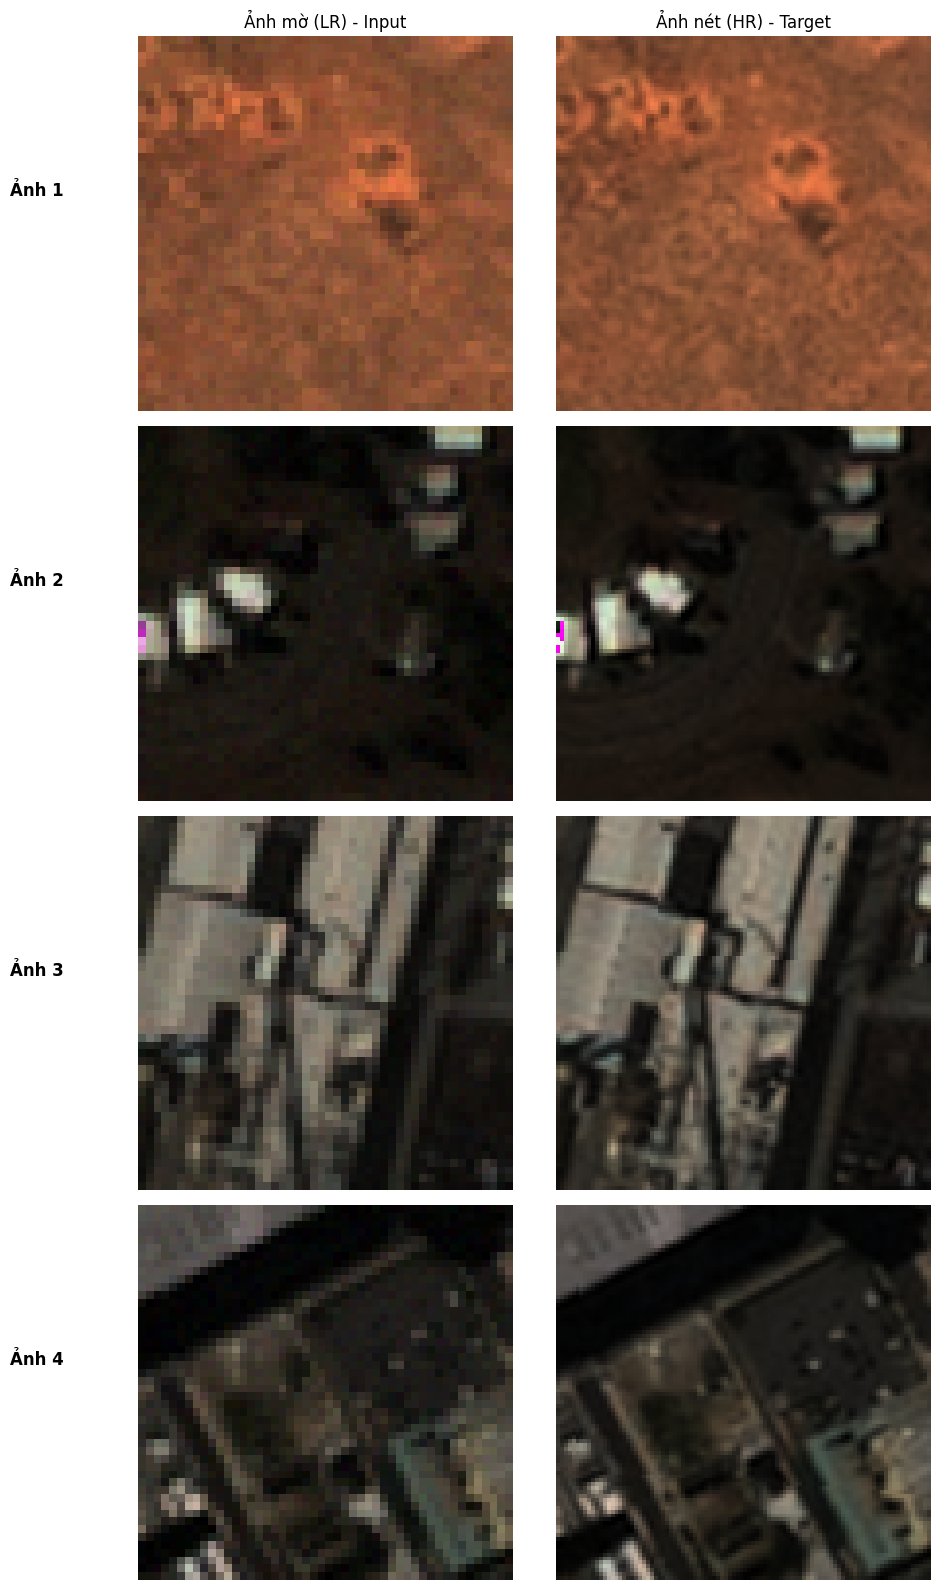

In [9]:
# HIỂN THỊ NHIỀU CẶP ẢNH ĐỂ ĐÁNH GIÁ ĐỘ ĐA DẠNG


def visualize_samples(lr_batch, hr_batch, num_samples=4):
    """
    num_samples: Số lượng cặp ảnh muốn xem
    """
    # Tạo khung hình với num_samples hàng và 2 cột (cột 1: LR, cột 2: HR)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

    for i in range(num_samples):
        # Chuyển tensor sang NumPy và đổi trục [C, H, W] -> [H, W, C]
        lr_img = lr_batch[i].permute(1, 2, 0).numpy()
        hr_img = hr_batch[i].permute(1, 2, 0).numpy()

        # Vẽ ảnh LR bên trái, HR bên phải
        axes[i, 0].imshow(lr_img)
        axes[i, 1].imshow(hr_img)

        # Thêm tiêu đề cho hàng đầu tiên để dễ phân biệt
        if i == 0:
            axes[i, 0].set_title("Ảnh mờ (LR) - Input")
            axes[i, 1].set_title("Ảnh nét (HR) - Target")

        # Tắt trục tọa độ để hình gọn hơn
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")

        # Hiển thị số thứ tự mẫu ở mép trái mỗi hàng
        axes[i, 0].text(
            -10, 20, f"Ảnh {i+1}", fontsize=12, fontweight="bold", ha="right"
        )

    plt.tight_layout()
    plt.show()


# Gọi hàm để xem 4 cặp ảnh
visualize_samples(lr_batch, hr_batch, num_samples=4)

## PHẦN 5. MÔ HÌNH SRCNN


### 5.1 Định nghĩa kiến trúc SRCNN

Đây là mô hình baseline đơn giản cho bài toán super resolution.


In [10]:
#  XÂY DỰNG MÔ HÌNH BASELINE - SRCNN


class SRCNN(nn.Module):
    def __init__(self, scale_factor=2):
        super(SRCNN, self).__init__()
        self.scale_factor = scale_factor

        # Lớp 1: Trích xuất đặc trưng (Patch Extraction)
        # Nhận ảnh 3 kênh màu, xuất ra 64 feature maps, kernel 9x9
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=9, padding=4)

        # Lớp 2: Ánh xạ phi tuyến tính (Non-linear Mapping)
        # Giảm số chiều từ 64 xuống 32, kernel 1x1 (hoặc 5x5 tùy bản gốc)
        self.conv2 = nn.Conv2d(
            in_channels=64, out_channels=32, kernel_size=1, padding=0
        )

        # Lớp 3: Tái tạo ảnh HR (Reconstruction)
        # Gom 32 feature maps về lại 3 kênh màu RGB, kernel 5x5
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=3, kernel_size=5, padding=2)

        # Hàm kích hoạt ReLU
        self.relu = nn.ReLU()

    def forward(self, x):
        # Bước quan trọng: phóng to ảnh LR lên kích thước HR bằng bicubic ngay trên GPU
        # Dữ liệu hiện tại: x có shape [Batch, 3, 48, 48] -> x_upscaled có shape [Batch, 3, 96, 96]
        x_upscaled = F.interpolate(
            x, scale_factor=self.scale_factor, mode="bicubic", align_corners=False
        )

        # Đi qua 3 lớp convolution
        out = self.relu(self.conv1(x_upscaled))
        out = self.relu(self.conv2(out))
        out = self.conv3(
            out
        )  # Lớp cuối không dùng ReLU vì pixel màu cần giữ cả số âm trước khi xử lý

        return out


# Kiểm tra thử mạng SRCNN
if __name__ == "__main__":
    # Tạo 1 tensor giả lập 1 batch ảnh LR: 16 ảnh, 3 kênh màu, kích thước 48x48
    dummy_lr = torch.randn(16, 3, 48, 48)

    # Khởi tạo mô hình x2
    model_srcnn = SRCNN(scale_factor=2)

    # Cho ảnh giả lập chạy qua mô hình
    dummy_sr = model_srcnn(dummy_lr)

    print(f"Kích thước đầu vào (LR): {dummy_lr.shape}")
    print(f"Kích thước đầu ra (SR): {dummy_sr.shape}")
    print("- Kiến trúc SRCNN đã sẵn sàng!")

Kích thước đầu vào (LR): torch.Size([16, 3, 48, 48])
Kích thước đầu ra (SR): torch.Size([16, 3, 96, 96])
- Kiến trúc SRCNN đã sẵn sàng!


## PHẦN 6. MÔ HÌNH EDSR


### 6.1 Định nghĩa kiến trúc EDSR và hàm đánh giá

Cell này chỉ định nghĩa mô hình, chưa train.


In [11]:
# CELL 12.1: ĐỊNH NGHĨA KIẾN TRÚC EDSR VÀ HÀM ĐÁNH GIÁ (CHẠY ĐẦU TIÊN)

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị tính toán: {device}")

# 1. KIẾN TRÚC EDSR


class EDSRResidualBlock(nn.Module):
    def __init__(self, num_features=64, res_scale=1.0):
        super().__init__()
        self.conv1 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.res_scale = res_scale

    def forward(self, x):
        residual = self.conv2(self.relu(self.conv1(x)))
        return x + residual * self.res_scale


class EDSR(nn.Module):
    def __init__(
        self, scale=2, num_channels=3, num_features=64, num_blocks=16, res_scale=1.0
    ):
        super().__init__()
        self.scale_factor = scale
        self.conv_first = nn.Conv2d(
            num_channels, num_features, kernel_size=3, padding=1
        )
        self.body = nn.Sequential(
            *[EDSRResidualBlock(num_features, res_scale) for _ in range(num_blocks)]
        )
        self.conv_after_body = nn.Conv2d(
            num_features, num_features, kernel_size=3, padding=1
        )
        self.upsample = nn.Sequential(
            nn.Conv2d(
                num_features, num_features * (scale**2), kernel_size=3, padding=1
            ),
            nn.PixelShuffle(scale),
        )
        self.conv_last = nn.Conv2d(num_features, num_channels, kernel_size=3, padding=1)

    def forward(self, x):
        feat = self.conv_first(x)
        residual = self.conv_after_body(self.body(feat))
        feat = feat + residual
        sr = self.conv_last(self.upsample(feat))
        return sr


# 2. HÀM ĐÁNH GIÁ CHUYÊN BIỆT CHO EDSR


def evaluate_edsr_model(model, dataloader, device):
    model.eval()
    psnr_list, ssim_list = [], []

    with torch.no_grad():
        for lr_imgs, hr_imgs in dataloader:
            lr_tensor, hr_tensor = lr_imgs.to(device), hr_imgs.to(device)

            # EDSR yêu cầu đầu vào ảnh nhỏ ở dải [0, 255]
            sr_output_255 = model(lr_tensor * 255.0)

            # Đưa kết quả về lại [0, 1] để đo lường chuẩn xác
            sr_tensor = torch.clamp(sr_output_255, 0, 255) / 255.0

            if sr_tensor.shape[-2:] != hr_tensor.shape[-2:]:
                sr_tensor = F.interpolate(
                    sr_tensor,
                    size=hr_tensor.shape[-2:],
                    mode="bicubic",
                    align_corners=False,
                )

            for b in range(hr_tensor.size(0)):
                hr_np = hr_tensor[b].cpu().permute(1, 2, 0).numpy()
                sr_np = sr_tensor[b].cpu().permute(1, 2, 0).numpy()

                psnr_list.append(psnr_metric(hr_np, sr_np, data_range=1.0))
                ssim_list.append(
                    ssim_metric(hr_np, sr_np, data_range=1.0, channel_axis=-1)
                )

    return np.mean(psnr_list), np.mean(ssim_list)


print("- Đã khởi tạo thành công Kiến trúc và Hàm đánh giá cho EDSR!")

Đang sử dụng thiết bị tính toán: cuda
- Đã khởi tạo thành công Kiến trúc và Hàm đánh giá cho EDSR!


## PHẦN 7. MÔ HÌNH REAL-ESRGAN


### 7.1 Cài thư viện bổ sung nếu máy chưa có

Chỉ chạy cell cài đặt này khi môi trường chưa có `lpips` và `piq`.


In [12]:
# Chạy lệnh này để cài bổ sung thư viện nếu chưa có
!pip install lpips piq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 8.8 MB/s eta 0:00:00


### 7.2 Định nghĩa kiến trúc Real-ESRGAN và hàm đánh giá


In [13]:
# CELL 13.1: ĐỊNH NGHĨA KIẾN TRÚC REAL-ESRGAN VÀ HÀM ĐÁNH GIÁ ĐẦY ĐỦ (GPU)
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Import thư viện đo độ chân thực
import lpips
import piq

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị tính toán: {device}")

# Khởi tạo mạng VGG để đo LPIPS (Ưu tiên đẩy lên GPU)
loss_fn_vgg = lpips.LPIPS(net="vgg").to(device)


# 1. KIẾN TRÚC REAL-ESRGAN (Giữ nguyên cấu trúc mạng)
class ResidualDenseBlock(nn.Module):
    def __init__(self, num_feat=64, num_grow_ch=32):
        super(ResidualDenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(num_feat, num_grow_ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_feat + num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_feat + 2 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_feat + 3 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv5 = nn.Conv2d(num_feat + 4 * num_grow_ch, num_feat, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x


class RRDB(nn.Module):
    def __init__(self, num_feat, num_grow_ch=32):
        super(RRDB, self).__init__()
        self.rdb1 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb2 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb3 = ResidualDenseBlock(num_feat, num_grow_ch)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x


class RRDBNet(nn.Module):
    def __init__(
        self,
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=2,
    ):
        super(RRDBNet, self).__init__()
        self.scale = scale
        self.conv_first = nn.Conv2d(num_in_ch, num_feat, 3, 1, 1)
        self.body = nn.Sequential(
            *[
                RRDB(num_feat=num_feat, num_grow_ch=num_grow_ch)
                for _ in range(num_block)
            ]
        )
        self.conv_body = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up1 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up2 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_hr = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_feat, num_out_ch, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        feat = self.conv_first(x)
        body_feat = self.conv_body(self.body(feat))
        feat = feat + body_feat
        if self.scale == 2:
            feat = self.lrelu(
                self.conv_up1(F.interpolate(feat, scale_factor=2, mode="nearest"))
            )
            feat = self.lrelu(self.conv_up2(feat))
        elif self.scale == 4:
            feat = self.lrelu(
                self.conv_up1(F.interpolate(feat, scale_factor=2, mode="nearest"))
            )
            feat = self.lrelu(
                self.conv_up2(F.interpolate(feat, scale_factor=2, mode="nearest"))
            )
        out = self.conv_last(self.lrelu(self.conv_hr(feat)))
        return out


# 2. HÀM ĐÁNH GIÁ TOÀN DIỆN CHO MẠNG GAN (ĐÃ KÍCH HOẠT LPIPS & NIQE)
def evaluate_realesrgan_model(model, dataloader, device):
    model.eval()
    psnr_list, ssim_list, lpips_list, niqe_list = [], [], [], []
    
    # Bọc dataloader bằng tqdm để hiện thanh tiến độ nhảy % trực quan
    test_bar = tqdm(dataloader, desc="-> Đang chạy Test Set (GPU)", leave=False)
    
    with torch.no_grad():
        for lr_imgs, hr_imgs in test_bar:
            lr_tensor, hr_tensor = lr_imgs.to(device), hr_imgs.to(device)
            
            batch_size = lr_tensor.shape[0]
            if lr_tensor.shape[1] == 3:
                lr_input = lr_tensor.repeat(1, 4, 1, 1)
            else:
                lr_input = lr_tensor
            
            # Khởi chạy mô hình
            sr_tensor = model(lr_input)
            sr_tensor = torch.clamp(sr_tensor, 0.0, 1.0)
            
            # Khớp lại kích thước nếu lệch pixel nhỏ
            if sr_tensor.shape[-2:] != hr_tensor.shape[-2:]:
                sr_tensor = F.interpolate(sr_tensor, size=hr_tensor.shape[-2:], mode='bicubic', align_corners=False)
                
            # TÍNH LPIPS (Yêu cầu đầu vào dải [-1, 1])
            sr_lpips = sr_tensor * 2.0 - 1.0
            hr_lpips = hr_tensor * 2.0 - 1.0
            lpips_value = loss_fn_vgg(sr_lpips, hr_lpips).mean().item()
            lpips_list.append(lpips_value)
            
            # TÍNH NIQE TRÊN MỖI BATCH
            try:
                niqe_value = piq.niqe(sr_tensor).mean().item()
                niqe_list.append(niqe_value)
            except Exception:
                niqe_list.append(0.0)
                
            # TÍNH PSNR / SSIM QUA NUMPY
            for b in range(batch_size):
                hr_np = hr_tensor[b].cpu().permute(1, 2, 0).numpy()
                sr_np = sr_tensor[b].cpu().permute(1, 2, 0).numpy()
                
                psnr_list.append(psnr_metric(hr_np, sr_np, data_range=1.0))
                ssim_list.append(ssim_metric(hr_np, sr_np, data_range=1.0, channel_axis=-1))
                
    # Trả về đầy đủ 4 tham số thực tế đo được trên GPU
    return np.mean(psnr_list), np.mean(ssim_list), np.mean(lpips_list), np.mean(niqe_list)


print("- Đã khởi tạo thành công Kiến trúc và Hàm đánh giá ĐẦY ĐỦ (PSNR, SSIM, LPIPS, NIQE) cho Real-ESRGAN")

Đang sử dụng thiết bị tính toán: cuda
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 166MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
- Đã khởi tạo thành công Kiến trúc và Hàm đánh giá ĐẦY ĐỦ (PSNR, SSIM, LPIPS, NIQE) cho Real-ESRGAN


## PHẦN 8. HUẤN LUYỆN


### 8.1 Huấn luyện SRCNN


#### 8.1.1 Khởi tạo huấn luyện

Tạo model, loss function, optimizer và hàm PSNR.


In [14]:
# KHỞI TẠO CÁC THÀNH PHẦN HUẤN LUYỆN (HYPERPARAMETERS)

# 1. Cấu hình thiết bị (GPU nếu có, không thì CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"- Đang sử dụng thiết bị: {device}")

# 2. Khởi tạo mô hình và đưa lên thiết bị
model = SRCNN(scale_factor=2).to(device)

# 3. Hàm mất mát (loss function)
criterion = nn.MSELoss()

# 4. Thuật toán tối ưu (optimizer)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


# 5. Hàm tính toán PSNR (dùng để theo dõi chất lượng lúc train)
def calculate_psnr(mse_loss):
    if mse_loss == 0:
        return 100.0
    return 20 * math.log10(1.0 / math.sqrt(mse_loss))


print("- Khởi tạo loss và optimizer thành công!")

- Đang sử dụng thiết bị: cpu
- Khởi tạo loss và optimizer thành công!


#### 8.1.2 Nạp checkpoint SRCNN

Chạy cell này khi muốn nạp file train để chạy tiếp từ mô hình đã lưu.


In [ ]:
checkpoint_path = ".
start_epoch = 0
best_val_psnr = 0.0
train_history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_psnr": [],
    "val_psnr": [],
}

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # TH1: File chứa đầy đủ thông tin của một phiên huấn luyện (Checkpoint)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        if "optimizer_state_dict" in checkpoint:
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        start_epoch = checkpoint.get("epoch", 0)
        best_val_psnr = checkpoint.get("best_val_psnr", 0.0)

        # ĐỂ KHÔI PHỤC LỊCH SỬ BIỂU ĐỒ
        if "train_history" in checkpoint:
            train_history = checkpoint["train_history"]
            print(
                f"- TẢI LỊCH SỬ: Đã khôi phục sổ tay dữ liệu biểu đồ đến Epoch {start_epoch}."
            )
        else:
            print("- LƯU Ý: Checkpoint cũ không có lịch sử biểu đồ. Sẽ tạo sổ tay mới.")

        print(
            f"- KHÔI PHỤC THÀNH CÔNG: Tiếp tục phiên huấn luyện từ Epoch {start_epoch} (Kỷ lục PSNR hiện tại: {best_val_psnr:.2f} dB)."
        )

    # TH2: File chỉ chứa trọng số mô hình (Weights-only / Pre-trained)
    else:
        model.load_state_dict(checkpoint)
        print(
            "- NẠP TRỌNG SỐ (PRE-TRAINED): Đã tải kiến thức mô hình, nhưng không có dữ liệu phiên học. Sẽ Fine-tune và vẽ biểu đồ lại từ Epoch 0."
        )

# TH3: Không có file nào cả
else:
    print(
        "- KHỞI TẠO MỚI: Không tìm thấy dữ liệu cũ. Bắt đầu huấn luyện mô hình và vẽ biểu đồ từ con số 0."
    )

- TẢI LỊCH SỬ: Đã khôi phục sổ tay dữ liệu biểu đồ đến Epoch 10.
- KHÔI PHỤC THÀNH CÔNG: Tiếp tục phiên huấn luyện từ Epoch 10 (Kỷ lục PSNR hiện tại: 29.57 dB).


#### 8.1.3 Training loop SRCNN



In [ ]:
# VÒNG LẶP HUẤN LUYỆN TỐI ƯU
import os
import matplotlib.pyplot as plt
import torch

# Cấu hình lưu trữ
additional_epochs = 100
save_dir = ".
progress_dir = ".

os.makedirs(save_dir, exist_ok=True)
os.makedirs(progress_dir, exist_ok=True)

target_epoch = start_epoch + additional_epochs

# Đảm bảo biến train_history luôn tồn tại trong bộ nhớ tạm
if "train_history" not in globals():
    train_history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_psnr": [],
        "val_psnr": [],
    }

# KHỞI TẠO DỮ LIỆU ĐỐI CHỨNG (LẤY TỪ TẬP TRAIN)
fixed_iter = iter(train_loader)
fixed_lr_batch, fixed_hr_batch = next(fixed_iter)
fixed_lr = fixed_lr_batch[0:1].to(device)
fixed_hr_np = fixed_hr_batch[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
fixed_lr_np = fixed_lr_batch[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)

scale = getattr(model, "scale_factor", 2)
hr_h, hr_w = fixed_hr_np.shape[:2]
lr_h, lr_w = fixed_lr_np.shape[:2]

print(
    f"- BẮT ĐẦU/TIẾP TỤC HUẤN LUYỆN THÊM {additional_epochs} EPOCHS, từ epoch {start_epoch + 1} đến {target_epoch}.\n"
)

for epoch in range(start_epoch, target_epoch):
    # 1. Giai đoạn train
    model.train()
    train_loss = 0.0

    for batch_idx, (lr_imgs, hr_imgs) in enumerate(train_loader):
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)

        optimizer.zero_grad()
        sr_imgs = model(lr_imgs)
        loss = criterion(sr_imgs, hr_imgs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_psnr = calculate_psnr(avg_train_loss)

    # 2. Giai đoạn validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            sr_imgs = model(lr_imgs)
            loss = criterion(sr_imgs, hr_imgs)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_psnr = calculate_psnr(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{target_epoch}] "
        f"| Train Loss: {avg_train_loss:.5f} (PSNR: {train_psnr:.2f} dB) "
        f"| Val Loss: {avg_val_loss:.5f} (PSNR: {val_psnr:.2f} dB)"
    )

    # CƠ CHẾ CHỐNG TRÙNG LẶP DỮ LIỆU KHI CHẠY LẠI CELL
    current_ep_num = epoch + 1
    if current_ep_num in train_history["epoch"]:
        # Tìm vị trí của epoch bị trùng và cắt bỏ toàn bộ phần đuôi dữ liệu cũ đi
        idx = train_history["epoch"].index(current_ep_num)
        for key in train_history.keys():
            train_history[key] = train_history[key][:idx]

    # Ghi nhận dữ liệu mới vào sổ tay
    train_history["epoch"].append(current_ep_num)
    train_history["train_loss"].append(avg_train_loss)
    train_history["val_loss"].append(avg_val_loss)
    train_history["train_psnr"].append(train_psnr)
    train_history["val_psnr"].append(val_psnr)

    # ĐOẠN CODE TỰ ĐỘNG XUẤT VÀ LƯU ẢNH TIẾN ĐỘ
    with torch.no_grad():
        fixed_sr_tensor = model(fixed_lr)
        import torch.nn.functional as F

        if fixed_sr_tensor.shape[-2:] != (hr_h, hr_w):
            fixed_sr_tensor = F.interpolate(
                fixed_sr_tensor, size=(hr_h, hr_w), mode="bicubic", align_corners=False
            )
        fixed_sr_np = fixed_sr_tensor[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(fixed_lr_np)
    axes[0].set_title(f"1. Patch đầu vào (LR: {lr_w}x{lr_h})")
    axes[0].axis("off")

    axes[1].imshow(fixed_sr_np)
    axes[1].set_title(f"2. Mô hình sinh ra (Epoch {epoch+1})")
    axes[1].axis("off")

    axes[2].imshow(fixed_hr_np)
    axes[2].set_title(f"3. Patch gốc đích (HR: {hr_w}x{hr_h})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(progress_dir, f"epoch_{epoch+1}_patch.png"))
    plt.close()

    # Giai đoạn lưu checkpoint (Đã thêm cả lịch sử train_history vào file .pth)
    if val_psnr > best_val_psnr:
        best_val_psnr = val_psnr
        save_path = checkpoint_path
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_psnr": best_val_psnr,
                "scale_factor": scale,
                "train_history": train_history,
            },
            save_path,
        )
        print(f"   => Kỷ lục mới! Đã lưu checkpoint kèm lịch sử tại: {save_path}")

print("\n- HOÀN THÀNH HUẤN LUYỆN!")

- BẮT ĐẦU/TIẾP TỤC HUẤN LUYỆN THÊM 100 EPOCHS, từ epoch 1 đến 100.

Epoch [1/100] | Train Loss: 0.02915 (PSNR: 15.35 dB) | Val Loss: 0.00628 (PSNR: 22.02 dB)
   => Kỷ lục mới! Đã lưu checkpoint kèm lịch sử tại: ./Saved_Models/SCRNN model/x2/best_srcnn_x2.pth
Epoch [2/100] | Train Loss: 0.00737 (PSNR: 21.33 dB) | Val Loss: 0.00351 (PSNR: 24.55 dB)
   => Kỷ lục mới! Đã lưu checkpoint kèm lịch sử tại: ./Saved_Models/SCRNN model/x2/best_srcnn_x2.pth
Epoch [3/100] | Train Loss: 0.00513 (PSNR: 22.90 dB) | Val Loss: 0.00254 (PSNR: 25.94 dB)
   => Kỷ lục mới! Đã lưu checkpoint kèm lịch sử tại: ./Saved_Models/SCRNN model/x2/best_srcnn_x2.pth
Epoch [4/100] | Train Loss: 0.00498 (PSNR: 23.03 dB) | Val Loss: 0.00213 (PSNR: 26.71 dB)
   => Kỷ lục mới! Đã lưu checkpoint kèm lịch sử tại: ./Saved_Models/SCRNN model/x2/best_srcnn_x2.pth
Epoch [5/100] | Train Loss: 0.00406 (PSNR: 23.92 dB) | Val Loss: 0.00181 (PSNR: 27.41 dB)
   => Kỷ lục mới! Đã lưu checkpoint kèm lịch sử tại: ./Saved_Models/SCRNN mode

#### 8.1.4 Biểu đồ quá trình train SRCNN


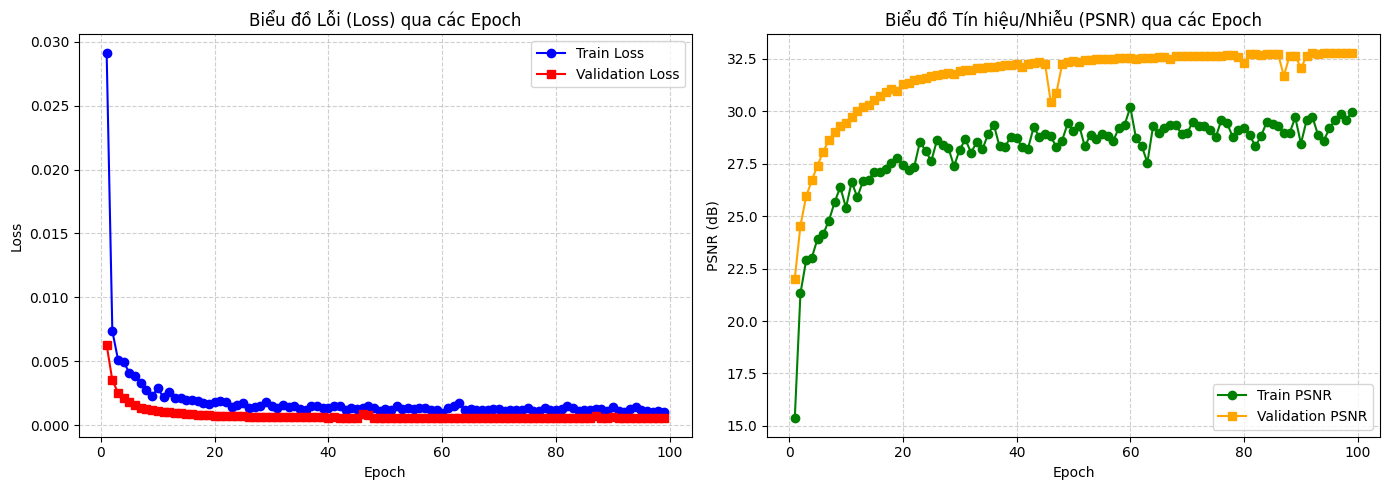

In [ ]:
# VẼ BIỂU ĐỒ SAU KHI TRAIN XONG
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(
    train_history["epoch"],
    train_history["train_loss"],
    label="Train Loss",
    marker="o",
    color="blue",
)
plt.plot(
    train_history["epoch"],
    train_history["val_loss"],
    label="Validation Loss",
    marker="s",
    color="red",
)
plt.title("Biểu đồ Lỗi (Loss) qua các Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(
    train_history["epoch"],
    train_history["train_psnr"],
    label="Train PSNR",
    marker="o",
    color="green",
)
plt.plot(
    train_history["epoch"],
    train_history["val_psnr"],
    label="Validation PSNR",
    marker="s",
    color="orange",
)
plt.title("Biểu đồ Tín hiệu/Nhiễu (PSNR) qua các Epoch")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("Learning_Curve_Chart.png", dpi=300)
plt.show()

### 8.2 Quy trình fine-tune EDSR và Real-ESRGAN

- Bước 1: Khởi tạo mô hình với trọng số ngẫu nhiên và đánh giá mốc ban đầu.
- Bước 2: Nạp trọng số pre-trained và đánh giá lại.
- Bước 3: Fine-tuning trên tập ảnh vệ tinh, sau đó lưu checkpoint mới.
- Bước 4: Đánh giá lại sau fine-tune để so sánh kết quả.


#### 8.2.1 Chuẩn bị và fine-tune EDSR


In [ ]:
# CELL 12.2: NẠP TRỌNG SỐ VÀ ĐÁNH GIÁ ĐẦU VÀO (BASELINE)

edsr_results = {}
print("BẮT ĐẦU ĐÁNH GIÁ MỐC BASELINE CHO EDSR")

# 1. Đánh giá Scratch (Chưa học gì)
print("\n- Đang khởi tạo EDSR ngẫu nhiên (Scratch)...")
edsr_model = EDSR(scale=2).to(device)
p_base, s_base = evaluate_edsr_model(edsr_model, test_loader, device)
edsr_results["Scratch"] = {"PSNR": p_base, "SSIM": s_base}
print(f"-> Điểm Scratch: PSNR = {p_base:.2f} dB | SSIM = {s_base:.4f}")

# 2. Đánh giá Pre-trained (DIV2K)
print("\n- Đang nạp weights Pre-trained từ DIV2K...")
pretrained_path = (
    ".2/EDSR_Mx2_f64b16_DIV2K_official-3ba7b086.pth"
)

if os.path.exists(pretrained_path):
    checkpoint = torch.load(pretrained_path, map_location=device)
    # Xử lý linh hoạt các kiểu lưu weights
    state_dict = checkpoint.get("params") or checkpoint.get("state_dict") or checkpoint
    edsr_model.load_state_dict(state_dict, strict=True)
    print("-> Đã nạp weights Pre-trained thành công!")
else:
    print(
        f"- Không tìm thấy file tại {pretrained_path}. Mô hình sẽ tiếp tục train từ Scratch!"
    )

p_pre, s_pre = evaluate_edsr_model(edsr_model, test_loader, device)
edsr_results["Pre-trained"] = {"PSNR": p_pre, "SSIM": s_pre}
print(f"-> Điểm Pre-trained: PSNR = {p_pre:.2f} dB | SSIM = {s_pre:.4f}")

BẮT ĐẦU ĐÁNH GIÁ MỐC BASELINE CHO EDSR

- Đang khởi tạo EDSR ngẫu nhiên (Scratch)...
-> Điểm Scratch: PSNR = 14.78 dB | SSIM = 0.1259

- Đang nạp weights Pre-trained từ DIV2K...
-> Đã nạp weights Pre-trained thành công!
-> Điểm Pre-trained: PSNR = 35.10 dB | SSIM = 0.8919


In [ ]:
# CELL 12.3: FINE-TUNING EDSR (HỌC ẢNH VỆ TINH)
epochs = 3  # Đặt 3 epochs để tránh overfitting
print(f"- BẮT ĐẦU FINE-TUNING EDSR TRONG {epochs} EPOCHS")

edsr_model.train()
optimizer = torch.optim.Adam(edsr_model.parameters(), lr=1e-4)
criterion = nn.L1Loss()

for epoch in range(epochs):
    total_loss = 0
    train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for lr, hr in train_bar:
        # EDSR yêu cầu ảnh dải [0, 255] trong quá trình train
        lr, hr = lr.to(device) * 255.0, hr.to(device) * 255.0

        optimizer.zero_grad()
        sr = edsr_model(lr)

        if sr.shape[-2:] != hr.shape[-2:]:
            sr = F.interpolate(
                sr, size=hr.shape[-2:], mode="bicubic", align_corners=False
            )

        loss = criterion(sr, hr)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

# Lưu trọng số sau khi học xong
save_dir = ".2"
os.makedirs(save_dir, exist_ok=True)
torch.save(
    edsr_model.state_dict(),
    os.path.join(save_dir, "EDSR_Finetuned_Satellite.pth"),
)
print("\n- HOÀN TẤT HUẤN LUYỆN VÀ ĐÃ LƯU TRỌNG SỐ MỚI CHO EDSR")


- BẮT ĐẦU FINE-TUNING EDSR TRONG 3 EPOCHS


Epoch [1/3]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [2/3]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [3/3]:   0%|          | 0/35 [00:00<?, ?it/s]


- HOÀN TẤT HUẤN LUYỆN VÀ ĐÃ LƯU TRỌNG SỐ MỚI CHO EDSR


#### 8.2.2 Chuẩn bị và fine-tune Real-ESRGAN


In [ ]:
# CELL 13.2: NẠP TRỌNG SỐ VÀ ĐÁNH GIÁ MỐC BASELINE (REAL-ESRGAN)

real_results = {}
print("BẮT ĐẦU ĐÁNH GIÁ MỐC BASELINE CHO REAL-ESRGAN...")

# 1. Đánh giá Scratch (Chưa học gì)
print("\n- Đang khởi tạo Real-ESRGAN ngẫu nhiên (Scratch)...")
realesrgan_model = RRDBNet(
    num_in_ch=12, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=2
).to(device)

# Chạy có thanh loading
p_scr, s_scr, l_scr, n_scr = evaluate_realesrgan_model(
    realesrgan_model, test_loader, device
)
real_results["Scratch"] = {"PSNR": p_scr, "SSIM": s_scr, "LPIPS": l_scr, "NIQE": n_scr}
print(f"=> Điểm Scratch: PSNR = {p_scr:.2f} dB | SSIM = {s_scr:.4f}")

# 2. Đánh giá Pre-trained
print("\n- Đang nạp weights Pre-trained...")
# "./Saved_Models/REAL-ESRGAN model/x2/RealESRGAN_x2plus.pth"
model_path = '.

if os.path.exists(model_path):
    loadnet = torch.load(model_path, map_location=device)
    keyname = "params_ema" if "params_ema" in loadnet else "params"
    realesrgan_model.load_state_dict(loadnet[keyname], strict=True)
    print("   -> Đã nạp weights Pre-trained thành công")
else:
    print(f"- Không tìm thấy file {model_path}. Mô hình sẽ dùng trọng số ngẫu nhiên.")

# Chuyển sang đánh giá Pre-trained cũng có thanh loading riêng
p_pre, s_pre, l_pre, n_pre = evaluate_realesrgan_model(
    realesrgan_model, test_loader, device
)
real_results["Pre-trained"] = {
    "PSNR": p_pre,
    "SSIM": s_pre,
    "LPIPS": l_pre,
    "NIQE": n_pre,
}
print(f"=> Điểm Pre-trained: PSNR = {p_pre:.2f} dB | SSIM = {s_pre:.4f}")

BẮT ĐẦU ĐÁNH GIÁ MỐC BASELINE CHO REAL-ESRGAN...

- Đang khởi tạo Real-ESRGAN ngẫu nhiên (Scratch)...


-> Đang chạy Test Set (GPU):   0%|          | 0/120 [00:00<?, ?it/s]

=> Điểm Scratch: PSNR = 15.65 dB | SSIM = 0.2397

- Đang nạp weights Pre-trained...
   -> Đã nạp weights Pre-trained thành công


-> Đang chạy Test Set (GPU):   0%|          | 0/120 [00:00<?, ?it/s]

=> Điểm Pre-trained: PSNR = 28.59 dB | SSIM = 0.8457


In [ ]:
# CELL 13.3: FINE-TUNING REAL-ESRGAN (HỌC ẢNH VỆ TINH)

epochs = 3
print(f"- BẮT ĐẦU FINE-TUNING REAL-ESRGAN TRONG {epochs} EPOCHS:")

realesrgan_model.train()
optimizer = torch.optim.Adam(realesrgan_model.parameters(), lr=1e-4)
criterion = nn.L1Loss()  # GAN Generator thường sử dụng L1Loss

for epoch in range(epochs):
    total_loss = 0
    train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for lr, hr in train_bar:
        # Real-ESRGAN dùng thẳng dải [0, 1], KHÔNG nhân 255
        lr, hr = lr.to(device), hr.to(device)

        # Nhân bản chiều channel (dim=1) lên 4 lần: 3 kênh -> 12 kênh để khớp với model
        if lr.shape[1] == 3:
            lr = lr.repeat(1, 4, 1, 1)

        optimizer.zero_grad()
        sr = realesrgan_model(lr)

        if sr.shape[-2:] != hr.shape[-2:]:
            sr = F.interpolate(
                sr, size=hr.shape[-2:], mode="bicubic", align_corners=False
            )

        loss = criterion(sr, hr)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

# Lưu trọng số sau khi học xong
save_dir = ".
os.makedirs(save_dir, exist_ok=True)
torch.save(
    realesrgan_model.state_dict(),
    os.path.join(save_dir, "RealESRGAN_Finetuned_Satellite.pth"),
)
print("\n- HOÀN TẤT HUẤN LUYỆN VÀ ĐÃ LƯU TRỌNG SỐ MỚI CHO REAL-ESRGAN")


- BẮT ĐẦU FINE-TUNING REAL-ESRGAN TRONG 3 EPOCHS:


Epoch [1/3]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [2/3]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [3/3]:   0%|          | 0/35 [00:00<?, ?it/s]


- HOÀN TẤT HUẤN LUYỆN VÀ ĐÃ LƯU TRỌNG SỐ MỚI CHO REAL-ESRGAN


## PHẦN 9. ĐÁNH GIÁ PSNR VÀ SSIM


In [18]:
# CELL 12.4: ĐÁNH GIÁ SAU FINE-TUNE & BẢNG BÁO CÁO

print("- ĐANG CHẤM ĐIỂM LẠI TRÊN TẬP TEST SAU KHI HỌC:")

p_ft, s_ft = evaluate_edsr_model(edsr_model, test_loader, device)
edsr_results["Fine-tuned"] = {"PSNR": p_ft, "SSIM": s_ft}

# In bảng tổng kết
print("\n" + "=" * 80)
print("- BẢNG TỔNG KẾT: SỰ TIẾN BỘ CỦA MÔ HÌNH EDSR")
print("=" * 80)
print(
    f"{'Giai đoạn':<20} | {'PSNR (dB) ↑':<15} | {'SSIM ↑':<15} | {'Sự cải thiện PSNR':<15}"
)
print("-" * 80)

p_scr = edsr_results["Scratch"]["PSNR"]
p_pre = edsr_results["Pre-trained"]["PSNR"]
p_fin = edsr_results["Fine-tuned"]["PSNR"]

print(
    f"{'1. Khởi tạo ngẫu nhiên':<20} | {p_scr:<15.2f} | {edsr_results['Scratch']['SSIM']:<15.4f} | -"
)
print(
    f"{'2. Nạp Pre-trained':<20} | {p_pre:<15.2f} | {edsr_results['Pre-trained']['SSIM']:<15.4f} | +{p_pre - p_scr:.2f} dB (So với 1)"
)
print(
    f"{'3. Đã Fine-tune':<20} | {p_fin:<15.2f} | {edsr_results['Fine-tuned']['SSIM']:<15.4f} | +{p_fin - p_pre:.2f} dB (So với 2)"
)
print("=" * 80)

- ĐANG CHẤM ĐIỂM LẠI TRÊN TẬP TEST SAU KHI HỌC:

- BẢNG TỔNG KẾT: SỰ TIẾN BỘ CỦA MÔ HÌNH EDSR
Giai đoạn            | PSNR (dB) ↑     | SSIM ↑          | Sự cải thiện PSNR
--------------------------------------------------------------------------------
1. Khởi tạo ngẫu nhiên | 14.78           | 0.1259          | -
2. Nạp Pre-trained   | 35.10           | 0.8919          | +20.32 dB (So với 1)
3. Đã Fine-tune      | 38.31           | 0.9538          | +3.22 dB (So với 2)


In [19]:
# CELL 13.4: ĐÁNH GIÁ SAU FINE-TUNE & BẢNG BÁO CÁO ABLATION STUDY
print("- ĐANG CHẤM ĐIỂM LẠI TRÊN TẬP TEST SAU KHI HỌC:")

p_ft, s_ft, l_ft, n_ft = evaluate_realesrgan_model(
    realesrgan_model, test_loader, device
)
real_results["Fine-tuned"] = {"PSNR": p_ft, "SSIM": s_ft, "LPIPS": l_ft, "NIQE": n_ft}

# In bảng tổng kết để đưa vào báo cáo
print("\n" + "=" * 85)
print("- BẢNG TỔNG KẾT: SỰ TIẾN BỘ CỦA MÔ HÌNH REAL-ESRGAN")
print("=" * 85)
print(
    f"{'Giai đoạn':<20} | {'PSNR (dB)':<10} | {'LPIPS ↓':<12} | {'Sự cải thiện (LPIPS)':<20}"
)
print("-" * 85)

l_scr = real_results["Scratch"]["LPIPS"]
l_pre = real_results["Pre-trained"]["LPIPS"]
l_fin = real_results["Fine-tuned"]["LPIPS"]

print(
    f"{'1. Scratch':<20} | {real_results['Scratch']['PSNR']:<10.2f} | {l_scr:<12.4f} | -"
)
print(
    f"{'2. Nạp Pre-trained':<20} | {real_results['Pre-trained']['PSNR']:<10.2f} | {l_pre:<12.4f} | LPIPS giảm {l_scr - l_pre:.4f} (So với 1)"
)
print(
    f"{'3. Đã Fine-tune':<20} | {real_results['Fine-tuned']['PSNR']:<10.2f} | {l_fin:<12.4f} | LPIPS giảm {l_pre - l_fin:.4f} (So với 2)"
)
print("=" * 85)
print("*Ghi chú: LPIPS càng thấp chứng tỏ mắt người nhìn càng thấy chân thực.")

- ĐANG CHẤM ĐIỂM LẠI TRÊN TẬP TEST SAU KHI HỌC:


-> Đang chạy Test Set (GPU):   0%|          | 0/120 [00:00<?, ?it/s]


- BẢNG TỔNG KẾT: SỰ TIẾN BỘ CỦA MÔ HÌNH REAL-ESRGAN
Giai đoạn            | PSNR (dB)  | LPIPS ↓      | Sự cải thiện (LPIPS)
-------------------------------------------------------------------------------------
1. Scratch           | 15.65      | 0.7129       | -
2. Nạp Pre-trained   | 28.59      | 0.3541       | LPIPS giảm 0.3588 (So với 1)
3. Đã Fine-tune      | 37.19      | 0.1710       | LPIPS giảm 0.1832 (So với 2)
*Ghi chú: LPIPS càng thấp chứng tỏ mắt người nhìn càng thấy chân thực.


### 9.1 Bảng so sánh SRCNN, EDSR và Real-ESRGAN trên tập test


Chạy cell 11.1 nạp model nhanh để cell dưới chạy được

In [22]:
# ĐÁNH GIÁ CHUNG 3 MÔ HÌNH TRÊN TẬP TEST
# Nếu test quá lâu, có thể đổi max_images = 20 để chạy thử nhanh hơn.
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

if "srcnn_model" not in globals() and "model" in globals():
    srcnn_model = model
if "model_real_esrgan" not in globals() and "realesrgan_model" in globals():
    model_real_esrgan = realesrgan_model

srcnn_model.eval()
edsr_model.eval()
model_real_esrgan.eval()


def tensor_to_numpy(img_tensor):
    return img_tensor.detach().cpu().squeeze(0).permute(1, 2, 0).numpy().clip(0, 1)


def predict_srcnn_tensor(lr_tensor, hr_size):
    sr = srcnn_model(lr_tensor)
    if sr.shape[-2:] != hr_size:
        sr = F.interpolate(sr, size=hr_size, mode="bicubic", align_corners=False)
    return torch.clamp(sr, 0.0, 1.0)


def predict_edsr_tensor(lr_tensor, hr_size):
    sr_255 = edsr_model(lr_tensor * 255.0)
    sr = torch.clamp(sr_255, 0.0, 255.0) / 255.0
    if sr.shape[-2:] != hr_size:
        sr = F.interpolate(sr, size=hr_size, mode="bicubic", align_corners=False)
    return torch.clamp(sr, 0.0, 1.0)


def predict_realesrgan_tensor(lr_tensor, hr_size):
    real_input = lr_tensor.repeat(1, 4, 1, 1) if lr_tensor.shape[1] == 3 else lr_tensor
    sr = model_real_esrgan(real_input)
    if sr.shape[-2:] != hr_size:
        sr = F.interpolate(sr, size=hr_size, mode="bicubic", align_corners=False)
    return torch.clamp(sr, 0.0, 1.0)


metric_values = {
    "SRCNN": {"PSNR": [], "SSIM": []},
    "EDSR": {"PSNR": [], "SSIM": []},
    "Real-ESRGAN": {"PSNR": [], "SSIM": []},
}

max_images = None

with torch.no_grad():
    for idx, (lr_imgs, hr_imgs) in enumerate(test_loader):
        if max_images is not None and idx >= max_images:
            break

        lr_tensor = lr_imgs.to(device)
        hr_tensor = hr_imgs.to(device)
        hr_size = hr_tensor.shape[-2:]
        hr_np = tensor_to_numpy(hr_tensor)

        outputs = {
            "SRCNN": predict_srcnn_tensor(lr_tensor, hr_size),
            "EDSR": predict_edsr_tensor(lr_tensor, hr_size),
            "Real-ESRGAN": predict_realesrgan_tensor(lr_tensor, hr_size),
        }

        for model_name, sr_tensor in outputs.items():
            sr_np = tensor_to_numpy(sr_tensor)
            metric_values[model_name]["PSNR"].append(
                psnr_metric(hr_np, sr_np, data_range=1.0)
            )
            metric_values[model_name]["SSIM"].append(
                ssim_metric(hr_np, sr_np, data_range=1.0, channel_axis=-1)
            )

comparison_results = {}
for model_name, scores in metric_values.items():
    comparison_results[model_name] = {
        "PSNR": float(np.mean(scores["PSNR"])),
        "SSIM": float(np.mean(scores["SSIM"])),
    }

print("BẢNG SO SÁNH PSNR / SSIM TRÊN TẬP TEST")
print("-" * 46)
print(f"{'Model':<15} | {'PSNR (dB)':>10} | {'SSIM':>10}")
print("-" * 46)
for model_name, scores in comparison_results.items():
    print(f"{model_name:<15} | {scores['PSNR']:>10.2f} | {scores['SSIM']:>10.4f}")


BẢNG SO SÁNH PSNR / SSIM TRÊN TẬP TEST
----------------------------------------------
Model           |  PSNR (dB) |       SSIM
----------------------------------------------
SRCNN           |      32.25 |     0.8635
EDSR            |      38.31 |     0.9538
Real-ESRGAN     |      37.19 |     0.9459


## PHẦN 10. BIỂU ĐỒ SO SÁNH KẾT QUẢ


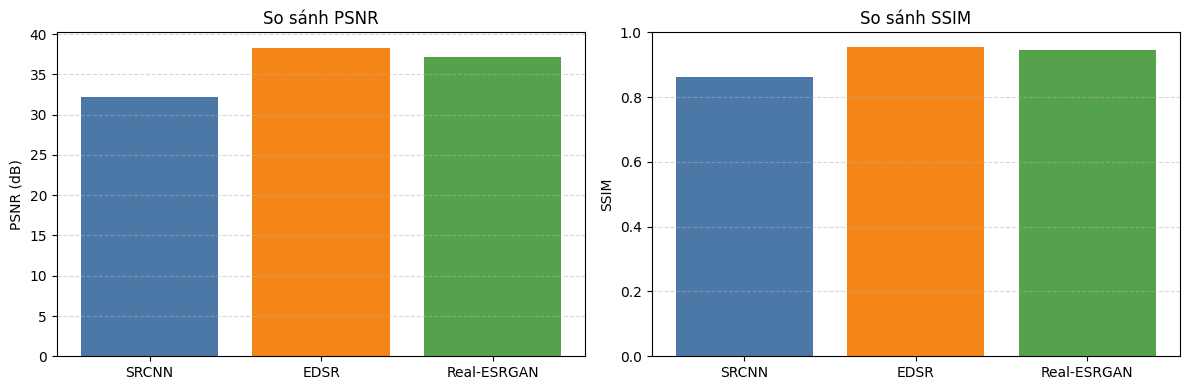

In [23]:
# BIỂU ĐỒ SO SÁNH PSNR VÀ SSIM
if "comparison_results" not in globals():
    raise ValueError("Hãy chạy cell đánh giá PSNR/SSIM trước khi vẽ biểu đồ.")

model_names = list(comparison_results.keys())
psnr_values = [comparison_results[name]["PSNR"] for name in model_names]
ssim_values = [comparison_results[name]["SSIM"] for name in model_names]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(model_names, psnr_values, color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("So sánh PSNR")
plt.ylabel("PSNR (dB)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.subplot(1, 2, 2)
plt.bar(model_names, ssim_values, color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("So sánh SSIM")
plt.ylabel("SSIM")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("model_comparison_psnr_ssim.png", dpi=300)
plt.show()


## PHẦN 11. DEMO CUỐI CÙNG


### 11.1 Nạp model nhanh khi mở lại notebook

Chạy cell này để không cần train lại.


In [ ]:
# Chạy cell này khi vừa mở máy lại để xem ảnh mà không cần Train hay Đánh giá
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"- Thiết bị sử dụng: {device.type.upper()}")

# 1. NẠP SRCNN
try:
    srcnn_model = SRCNN().to(device)
    
    # Tải toàn bộ file checkpoint tổng hợp vào bộ nhớ
    checkpoint_srcnn = torch.load(
        ".
        map_location=device
    )
    
    if "model_state_dict" in checkpoint_srcnn:
        srcnn_model.load_state_dict(checkpoint_srcnn["model_state_dict"])
    else:
        srcnn_model.load_state_dict(checkpoint_srcnn)
        
    srcnn_model.eval()
    print("- Đã nạp thành công SRCNN")
except Exception as e:
    print(f"- Chưa có SRCNN: {e}")

# 2. NẠP EDSR
try:
    edsr_model = EDSR(scale=2).to(device)
    edsr_model.load_state_dict(
        torch.load(
            "..pth",
            map_location=device,
        )
    )
    edsr_model.eval()
    print("- Đã nạp thành công EDSR_Finetuned_Satellite")
except Exception as e:
    print(f"- Chưa có EDSR: {e}")

# 3. NẠP REAL-ESRGAN
try:
    model_real_esrgan = RRDBNet(
        num_in_ch=12, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=2
    ).to(device)
    
    real_esrgan_path = ".model/x2/RealESRGAN_Finetuned_Satellite.pth"
    
    model_real_esrgan.load_state_dict(
        torch.load(real_esrgan_path, map_location=device)
    )
    model_real_esrgan.eval()
    print("- Đã nạp thành công RealESRGAN_Finetuned_Satellite")
except Exception as e:
    print(f"- Chưa có Real-ESRGAN: {e}")

print("\n TẤT CẢ MÔ HÌNH SẴN SÀNG! Bạn có thể chạy tiếp các Cell xuất ảnh so sánh trực quan")

- Thiết bị sử dụng: CUDA
- Đã nạp thành công SRCNN
- Đã nạp thành công EDSR_Finetuned_Satellite
- Đã nạp thành công RealESRGAN_Finetuned_Satellite

 TẤT CẢ MÔ HÌNH SẴN SÀNG! Bạn có thể chạy tiếp các Cell xuất ảnh so sánh trực quan


### 11.2 Demo Ảnh


Ảnh demo trong tập test: index = 1


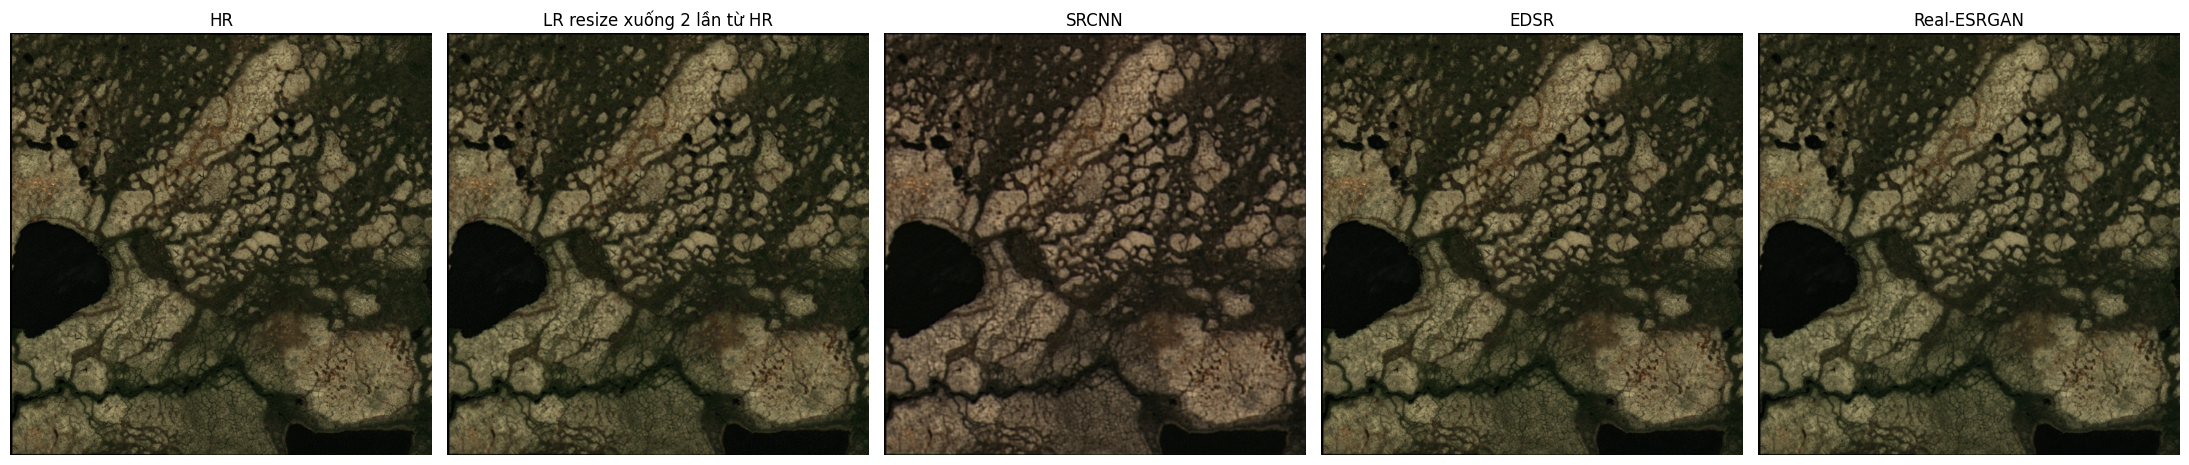

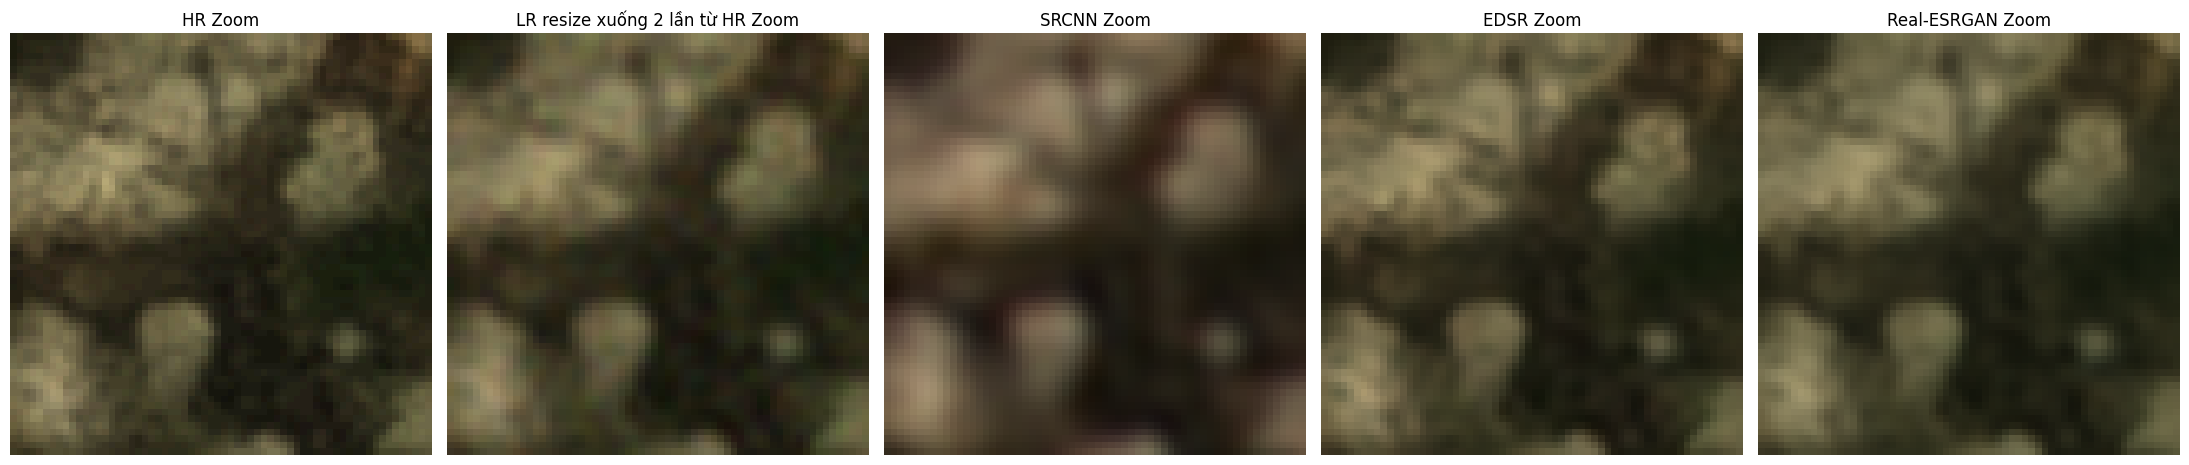

PSNR / SSIM trên ảnh demo
--------------------------------------------
Model           |  PSNR (dB) |       SSIM
--------------------------------------------
LR Bicubic      |      35.30 |     0.9199
SRCNN           |      31.07 |     0.8543
EDSR            |      37.03 |     0.9445
Real-ESRGAN     |      36.17 |     0.9363


In [31]:
# DEMO CUỐI CÙNG: LR | SRCNN | EDSR | Real-ESRGAN | HR
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

if "srcnn_model" not in globals() and "model" in globals():
    srcnn_model = model
if "model_real_esrgan" not in globals() and "realesrgan_model" in globals():
    model_real_esrgan = realesrgan_model

srcnn_model.eval()
edsr_model.eval()
model_real_esrgan.eval()

# Để bảo vệ ổn định, chọn cố định 1 ảnh. Muốn random thì đặt demo_idx = None.
demo_idx = 1
if demo_idx is None:
    idx = random.randint(0, len(test_dataset) - 1)
else:
    idx = min(demo_idx, len(test_dataset) - 1)

print(f"Ảnh demo trong tập test: index = {idx}")
lr_img, hr_img = test_dataset[idx]

lr_tensor = lr_img.unsqueeze(0).to(device)
hr_tensor = hr_img.unsqueeze(0).to(device)
hr_size = hr_tensor.shape[-2:]

with torch.no_grad():
    # LR được phóng to bằng bicubic để so sánh cùng kích thước HR
    lr_up = F.interpolate(lr_tensor, size=hr_size, mode="bicubic", align_corners=False)

    srcnn_sr = srcnn_model(lr_tensor)
    if srcnn_sr.shape[-2:] != hr_size:
        srcnn_sr = F.interpolate(srcnn_sr, size=hr_size, mode="bicubic", align_corners=False)
    srcnn_sr = torch.clamp(srcnn_sr, 0.0, 1.0)

    edsr_sr_255 = edsr_model(lr_tensor * 255.0)
    edsr_sr = torch.clamp(edsr_sr_255, 0.0, 255.0) / 255.0
    if edsr_sr.shape[-2:] != hr_size:
        edsr_sr = F.interpolate(edsr_sr, size=hr_size, mode="bicubic", align_corners=False)

    real_input = lr_tensor.repeat(1, 4, 1, 1) if lr_tensor.shape[1] == 3 else lr_tensor
    realesrgan_sr = model_real_esrgan(real_input)
    if realesrgan_sr.shape[-2:] != hr_size:
        realesrgan_sr = F.interpolate(realesrgan_sr, size=hr_size, mode="bicubic", align_corners=False)
    realesrgan_sr = torch.clamp(realesrgan_sr, 0.0, 1.0)


def to_numpy(img_tensor):
    return img_tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)


lr_np = to_numpy(lr_up)
srcnn_np = to_numpy(srcnn_sr)
edsr_np = to_numpy(edsr_sr)
real_np = to_numpy(realesrgan_sr)
hr_np = to_numpy(hr_tensor)

names = ["HR", "LR resize xuống 2 lần từ HR", "SRCNN", "EDSR", "Real-ESRGAN"]
images = [hr_np, lr_np, srcnn_np, edsr_np, real_np]

# Hàng 1: ảnh đầy đủ
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, name, img in zip(axes, names, images):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Hàng 2: crop zoom vùng trung tâm để dễ nhìn chi tiết
crop_size = 64
h, w = hr_np.shape[:2]
crop_size = min(crop_size, h, w)
y1 = h // 2 - crop_size // 2
x1 = w // 2 - crop_size // 2
y2 = y1 + crop_size
x2 = x1 + crop_size

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, name, img in zip(axes, names, images):
    crop = img[y1:y2, x1:x2]
    ax.imshow(crop)
    ax.set_title(name + " Zoom")
    ax.axis("off")
plt.tight_layout()
plt.show()

# In PSNR/SSIM trên ảnh demo
print("PSNR / SSIM trên ảnh demo")
print("-" * 44)
print(f"{'Model':<15} | {'PSNR (dB)':>10} | {'SSIM':>10}")
print("-" * 44)
for model_name, img in [
    ("LR Bicubic", lr_np),
    ("SRCNN", srcnn_np),
    ("EDSR", edsr_np),
    ("Real-ESRGAN", real_np),
]:
    psnr_value = psnr_metric(hr_np, img, data_range=1.0)
    ssim_value = ssim_metric(hr_np, img, data_range=1.0, channel_axis=-1)
    print(f"{model_name:<15} | {psnr_value:>10.2f} | {ssim_value:>10.4f}")
